<a href="https://colab.research.google.com/github/versyy35/dsf-assignment/blob/main/G08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Group__08

**Tutorial section: TT1L**


| | Student ID     | Student Name                           | Contribution |
|--:|:-------------|:---------------------------------------|-------------:|
| 1 | 1211111809  | Maryam binti Norazman                   | 25%          |
| 2 | 1231303436  | Nur Zahidah Binti Zahrul Ariffin        | 25%          |
| 3 | 1211111950  | Adam Fikri bin Mohd Lotfi               | 25%          |
| 4 | 251UC2519B  | Nur Aryssa Syauqina binti Mohd Faizul   | 25%          |


In [16]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [17]:
# Read csv file
df = pd.read_csv("/ai4i2020.csv")
# Quick overview
print("Shape:", df.shape)   # rows, columns
print("\nColumn Info:\n", df.dtypes)   # data types
print("\nMissing Values:\n", df.isnull().sum())   # missing values per column
print("\nDuplicate Rows:", df.duplicated().sum()) # count duplicates
# View first 5 rows
df.head(5)

Shape: (10000, 14)

Column Info:
 UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing Values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate Rows: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [18]:
# Cleaned dataset
df_clean = df.copy()

# Drop irrelevant column (Product ID and UDI)
df_clean = df_clean.drop(columns=["Product ID", "UDI"])
print ("Column after dropping: ", df_clean.columns.tolist())

Column after dropping:  ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [19]:
# Identify categorical columns
categorical_col = df_clean.select_dtypes(include=["object"]).columns
print("Categorical columns: ", categorical_col)

#Encode categorical column if exist
if "Type" in categorical_col:
    df_clean = pd.get_dummies(df_clean, columns=["Type"], drop_first=True)

print("Original data shape:",df.shape)
print("Cleaned data shape:", df_clean.shape)

df_clean.head()

Categorical columns:  Index(['Type'], dtype='object')
Original data shape: (10000, 14)
Cleaned data shape: (10000, 13)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [26]:
# Missing values analysis
print("=" * 80)
print("                          MISSING VALUES ANALYSIS")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_df.to_string(index=False))
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

                          MISSING VALUES ANALYSIS
                 Column  Missing Count  Missing %
                    UDI              0        0.0
             Product ID              0        0.0
                   Type              0        0.0
    Air temperature [K]              0        0.0
Process temperature [K]              0        0.0
 Rotational speed [rpm]              0        0.0
            Torque [Nm]              0        0.0
        Tool wear [min]              0        0.0
        Machine failure              0        0.0
                    TWF              0        0.0
                    HDF              0        0.0
                    PWF              0        0.0
                    OSF              0        0.0
                    RNF              0        0.0

Total Missing Values: 0


In [31]:
# Duplicate rows analysis
print("\n" + "=" * 80)
print("                             DUPLICATE ROWS ANALYSIS")
print("=" * 80)

duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count}")
print(f"Duplicate Percentage: {(duplicate_count / len(df) * 100):.2f}%")


                             DUPLICATE ROWS ANALYSIS
Duplicate Rows: 0
Duplicate Percentage: 0.00%


In [37]:
# Unique values per column
print("\n" + "=" * 80)
print("                            UNIQUE VALUES PER COLUMN")
print("=" * 80)

unique_df = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': df.nunique().values,
    'Data Type': df.dtypes.values
})
print(unique_df.to_string(index=False))


                            UNIQUE VALUES PER COLUMN
                 Column  Unique Values Data Type
                    UDI          10000     int64
             Product ID          10000    object
                   Type              3    object
    Air temperature [K]             93   float64
Process temperature [K]             82   float64
 Rotational speed [rpm]            941     int64
            Torque [Nm]            577   float64
        Tool wear [min]            246     int64
        Machine failure              2     int64
                    TWF              2     int64
                    HDF              2     int64
                    PWF              2     int64
                    OSF              2     int64
                    RNF              2     int64


In [39]:
# Define reusable cleaning functions
def drop_irrelevant_columns(df, columns_to_drop):
    """Drop specified columns from dataframe."""
    # Filter to ensure only existing columns are dropped
    existing_cols = [col for col in columns_to_drop if col in df.columns]
    print(f"Dropping columns: {existing_cols}")
    return df.drop(columns=existing_cols)
def encode_categorical(df, columns=None):
    """One-hot encode categorical columns."""
    # Identify categorical columns if not specified
    if columns is None:
        columns = df.select_dtypes(include=['object']).columns.tolist()

    # Perform one-hot encoding if categorical columns exist
    if columns:
        print(f"Encoding categorical columns: {columns}")
        df = pd.get_dummies(df, columns=columns, drop_first=True)
    return df
def remove_duplicates(df):
    """Remove duplicate rows."""
    # Calculate initial row count
    initial_rows = len(df)
    # Drop duplicate rows
    df = df.drop_duplicates()
    # Calculate number of removed duplicates
    removed = initial_rows - len(df)
    print(f"Removed {removed} duplicate rows")
    return df
def handle_missing_values(df, strategy='drop', fill_value=None):
    """Handle missing values with various strategies."""
    # Count missing values before handling
    missing_count = df.isnull().sum().sum()
    print(f"Missing values before: {missing_count}")
    # Apply specified strategy for handling missing values
    if strategy == 'drop':
        df = df.dropna()
    elif strategy == 'mean':
        df = df.fillna(df.mean(numeric_only=True))
    elif strategy == 'median':
        df = df.fillna(df.median(numeric_only=True))
    elif strategy == 'mode':
        df = df.fillna(df.mode().iloc[0])
    elif strategy == 'constant':
        df = df.fillna(fill_value)
    # Count missing values after handling
    print(f"Missing values after: {df.isnull().sum().sum()}")
    return df

In [40]:
# Apply Cleaning Pipeline using .pipe()
df_clean = df.copy()

print("=" * 80)
print("APPLYING DATA CLEANING PIPELINE")
print("=" * 80)
print(f"\nOriginal shape: {df_clean.shape}")

APPLYING DATA CLEANING PIPELINE

Original shape: (10000, 14)


In [41]:
# Step 1: Drop irrelevant columns
print("\n--- Step 1: Drop Irrelevant Columns ---")
df_clean = df_clean.pipe(drop_irrelevant_columns, ['UDI', 'Product ID'])


--- Step 1: Drop Irrelevant Columns ---
Dropping columns: ['UDI', 'Product ID']


In [42]:
# Step 2: Remove duplicates
print("\n--- Step 2: Remove Duplicates ---")
df_clean = df_clean.pipe(remove_duplicates)


--- Step 2: Remove Duplicates ---
Removed 0 duplicate rows


In [44]:
# Step 3: Handle missing values
print("\n--- Step 3: Handle Missing Values ---")
df_clean = df_clean.pipe(handle_missing_values, strategy='drop')


--- Step 3: Handle Missing Values ---
Missing values before: 0
Missing values after: 0


In [45]:
# Step 4: Encode categorical variables
print("\n--- Step 4: Encode Categorical Variables ---")
df_clean = df_clean.pipe(encode_categorical, columns=['Type'])


--- Step 4: Encode Categorical Variables ---
Encoding categorical columns: ['Type']


In [46]:
print(f"\nFinal cleaned shape: {df_clean.shape}")


Final cleaned shape: (10000, 13)


In [47]:
# Create analysis version (keeping Type as categorical)
df_analysis = df.drop(columns=['UDI', 'Product ID']).copy()

In [79]:
# Define sensor columns for analysis
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Descriptive statistics
print("=" * 80)
print("                  DESCRIPTIVE STATISTICS - SENSOR VARIABLES")
print("=" * 80)

stats_df = df[sensor_cols].describe().T
stats_df['variance'] = df[sensor_cols].var()
stats_df['skewness'] = df[sensor_cols].skew()
stats_df['kurtosis'] = df[sensor_cols].kurtosis()
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
print(stats_df.round(2))

                  DESCRIPTIVE STATISTICS - SENSOR VARIABLES
                           count     mean     std     min     25%     50%  \
Air temperature [K]      10000.0   300.00    2.00   295.3   298.3   300.1   
Process temperature [K]  10000.0   310.01    1.48   305.7   308.8   310.1   
Rotational speed [rpm]   10000.0  1538.78  179.28  1168.0  1423.0  1503.0   
Torque [Nm]              10000.0    39.99    9.97     3.8    33.2    40.1   
Tool wear [min]          10000.0   107.95   63.65     0.0    53.0   108.0   

                            75%     max  variance  skewness  kurtosis    IQR  
Air temperature [K]       301.5   304.5      4.00      0.11     -0.84    3.2  
Process temperature [K]   311.1   313.8      2.20      0.02     -0.50    2.3  
Rotational speed [rpm]   1612.0  2886.0  32142.79      1.99      7.39  189.0  
Torque [Nm]                46.8    76.6     99.38     -0.01     -0.01   13.6  
Tool wear [min]           162.0   253.0   4051.85      0.03     -1.17  109.0  


In [76]:
# Target variable distribution
print("\n" + "=" * 80)
print("                  TARGET VARIABLE DISTRIBUTION (Machine Failure)")
print("=" * 80)

failure_dist = df['Machine failure'].value_counts()
failure_pct = df['Machine failure'].value_counts(normalize=True) * 100

print(f"\nNo Failure (0): {failure_dist[0]:,} ({failure_pct[0]:.2f}%)")
print(f"Failure (1):    {failure_dist[1]:,} ({failure_pct[1]:.2f}%)")
print(f"\nClass Imbalance Ratio: {failure_dist[0]/failure_dist[1]:.1f}:1")


                  TARGET VARIABLE DISTRIBUTION (Machine Failure)

No Failure (0): 9,661 (96.61%)
Failure (1):    339 (3.39%)

Class Imbalance Ratio: 28.5:1


In [73]:
# Failure type distribution
print("\n" + "=" * 80)
print("                           FAILURE TYPE DISTRIBUTION")
print("=" * 80)

failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

failure_counts = df[failure_types].sum().sort_values(ascending=False)
for ft in failure_counts.index:
    count = failure_counts[ft]
    pct = (count / len(df)) * 100
    print(f"  {failure_names[ft]:28s} ({ft}): {count:3d} ({pct:.2f}%)")


                           FAILURE TYPE DISTRIBUTION
  Heat Dissipation Failure     (HDF): 115 (1.15%)
  Overstrain Failure           (OSF):  98 (0.98%)
  Power Failure                (PWF):  95 (0.95%)
  Tool Wear Failure            (TWF):  46 (0.46%)
  Random Failure               (RNF):  19 (0.19%)


In [71]:
# Grouped analysis by Product Type
print("\n" + "=" * 80)
print("                        FAILURE RATE BY PRODUCT TYPE")
print("=" * 80)

failure_by_type = df_analysis.groupby('Type').agg({
    'Machine failure': ['sum', 'count', 'mean']
}).round(4)
failure_by_type.columns = ['Failures', 'Total', 'Failure Rate']
failure_by_type['Failure Rate %'] = (failure_by_type['Failure Rate'] * 100).round(2)
print(failure_by_type)


                        FAILURE RATE BY PRODUCT TYPE
      Failures  Total  Failure Rate  Failure Rate %
Type                                               
H           21   1003        0.0209            2.09
L          235   6000        0.0392            3.92
M           83   2997        0.0277            2.77


In [68]:
# Correlation analysis
print("\n" + "=" * 80)
print("                      CORRELATION WITH MACHINE FAILURE")
print("=" * 80)

corr_cols = sensor_cols + ['Machine failure'] + failure_types
correlation_matrix = df[corr_cols].corr()
print(correlation_matrix['Machine failure'].sort_values(ascending=False).round(4))


                      CORRELATION WITH MACHINE FAILURE
Machine failure            1.0000
HDF                        0.5758
OSF                        0.5311
PWF                        0.5228
TWF                        0.3629
Torque [Nm]                0.1913
Tool wear [min]            0.1054
Air temperature [K]        0.0826
Process temperature [K]    0.0359
RNF                        0.0045
Rotational speed [rpm]    -0.0442
Name: Machine failure, dtype: float64


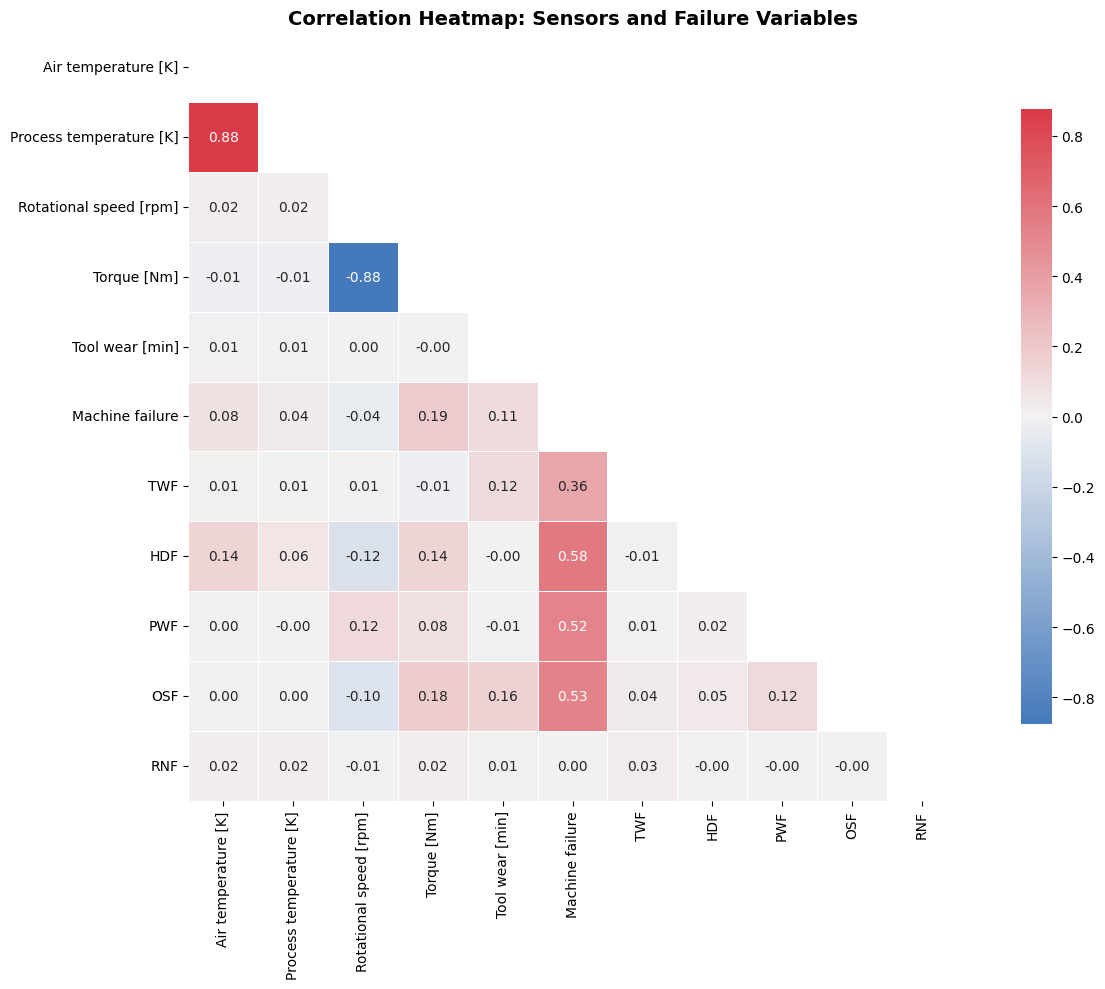

In [49]:
# VISUALIZATION 1: Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap: Sensors and Failure Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

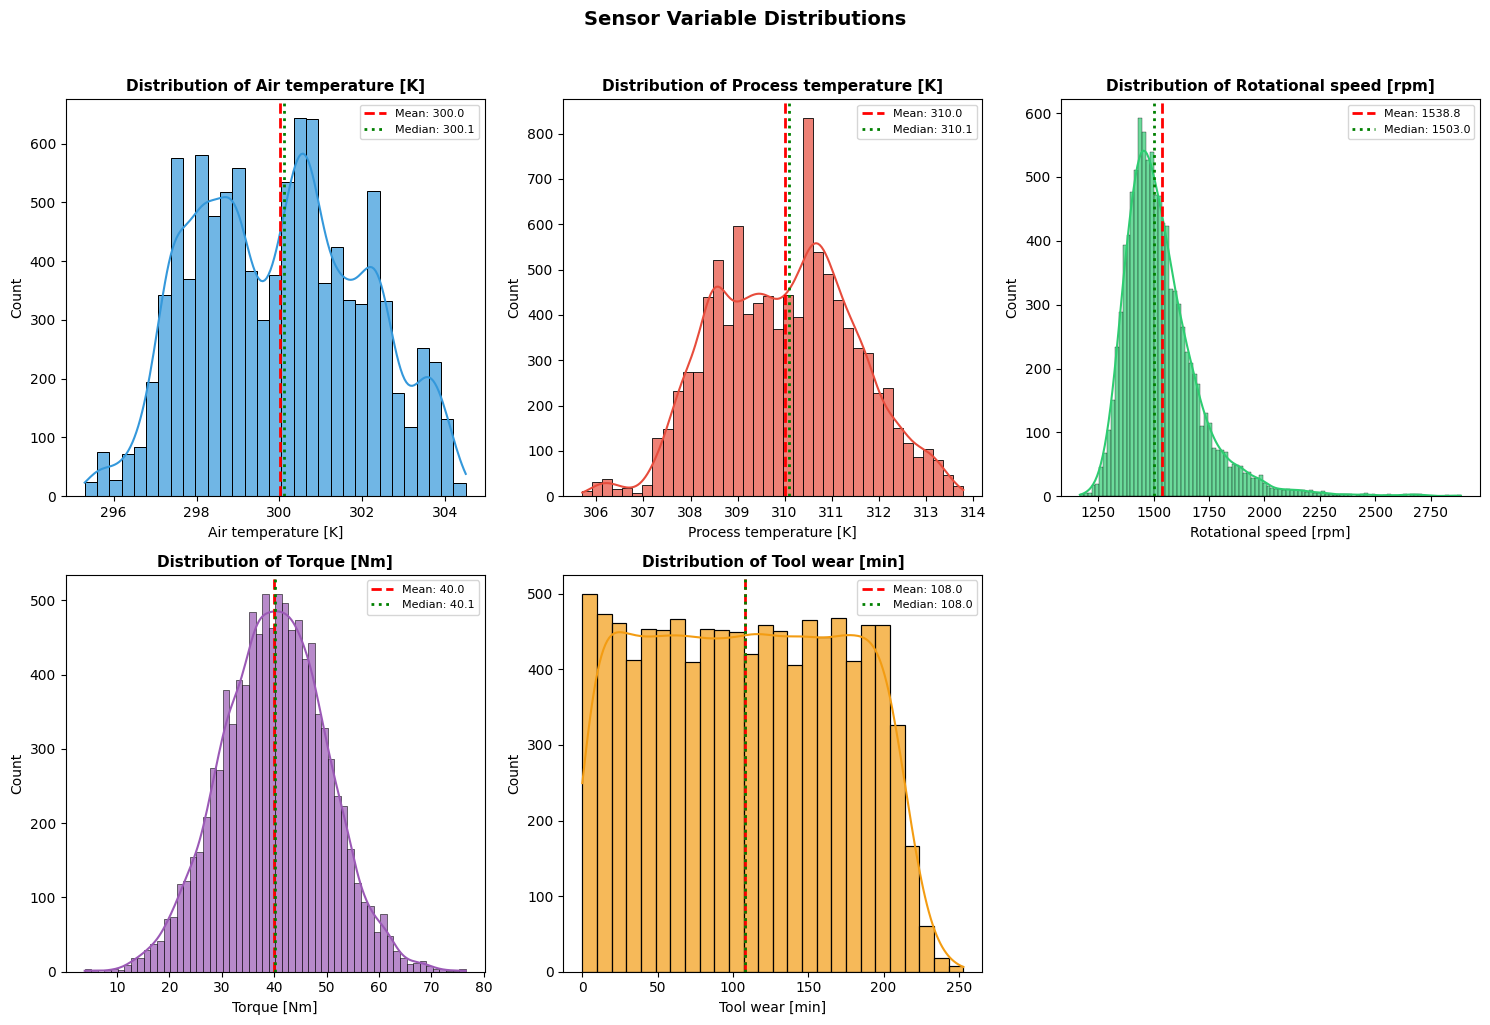

In [50]:
# VISUALIZATION 2: Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for idx, col in enumerate(sensor_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color=colors[idx], alpha=0.7, edgecolor='black')
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Median: {median_val:.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Sensor Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

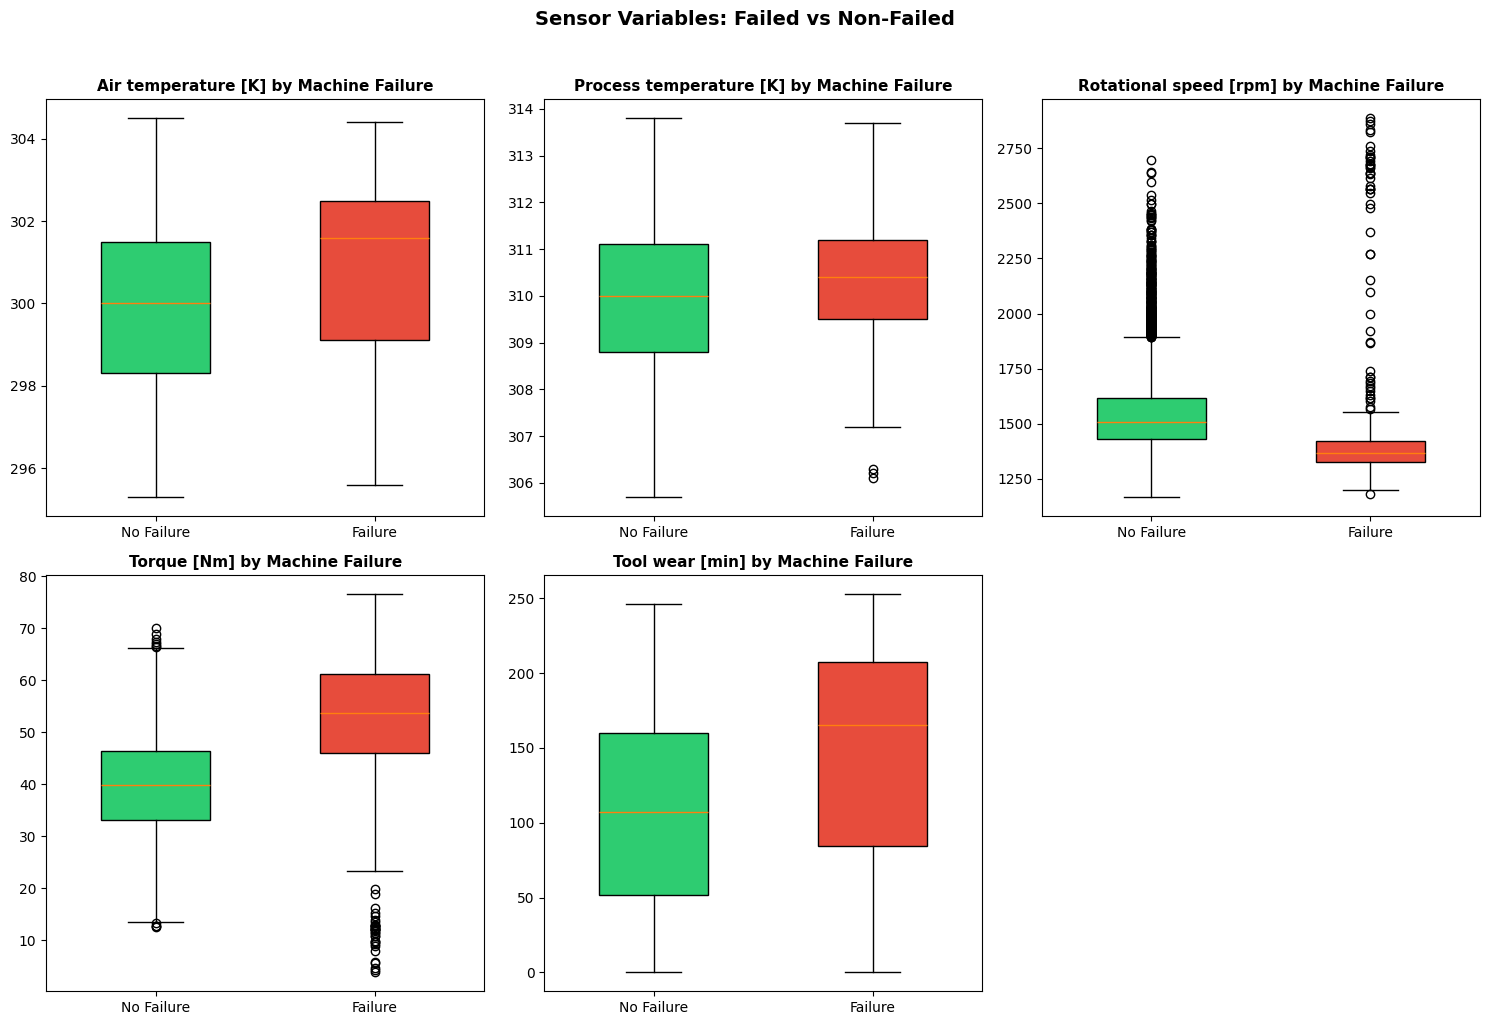

In [51]:
# VISUALIZATION 3: Boxplots by Machine Failure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    ax = axes[idx]
    no_fail = df[df['Machine failure'] == 0][col]
    fail = df[df['Machine failure'] == 1][col]
    bp = ax.boxplot([no_fail, fail], labels=['No Failure', 'Failure'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(f'{col} by Machine Failure', fontsize=11, fontweight='bold')

axes[5].axis('off')
plt.suptitle('Sensor Variables: Failed vs Non-Failed', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_boxplots_by_failure.png', dpi=150, bbox_inches='tight')
plt.show()

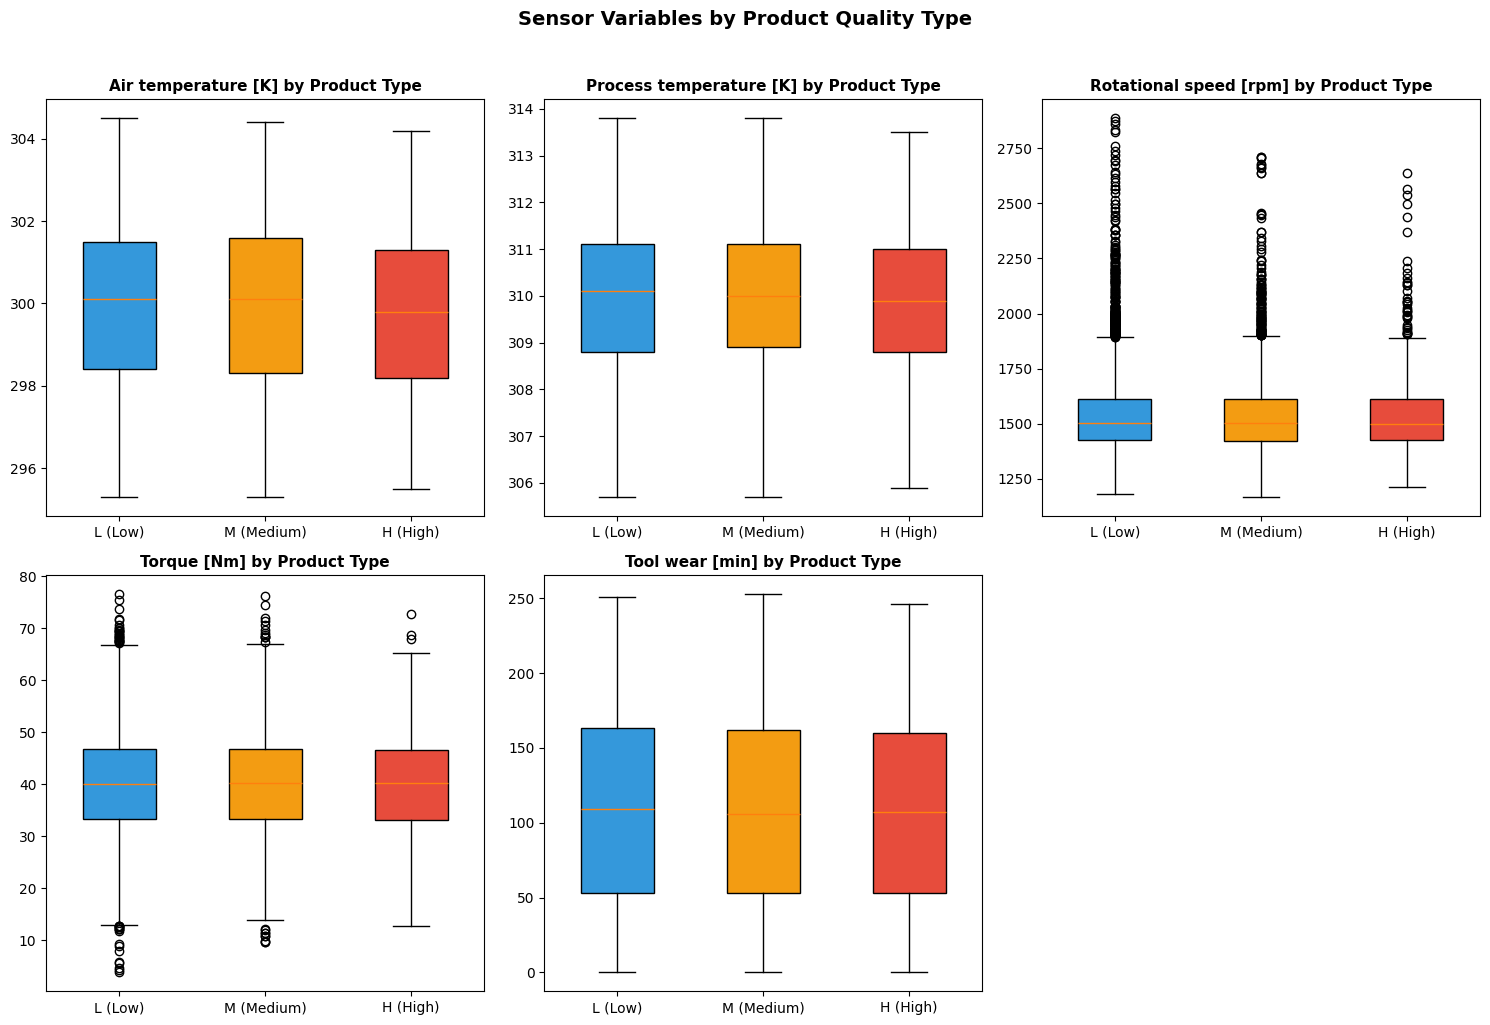

In [52]:
# VISUALIZATION 4: Boxplots by Product Type
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(sensor_cols):
    ax = axes[idx]
    data_by_type = [df_analysis[df_analysis['Type'] == t][col] for t in ['L', 'M', 'H']]
    bp = ax.boxplot(data_by_type, labels=['L (Low)', 'M (Medium)', 'H (High)'],
                    patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['#3498db', '#f39c12', '#e74c3c']):
        patch.set_facecolor(color)
    ax.set_title(f'{col} by Product Type', fontsize=11, fontweight='bold')

axes[5].axis('off')
plt.suptitle('Sensor Variables by Product Quality Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_04_boxplots_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

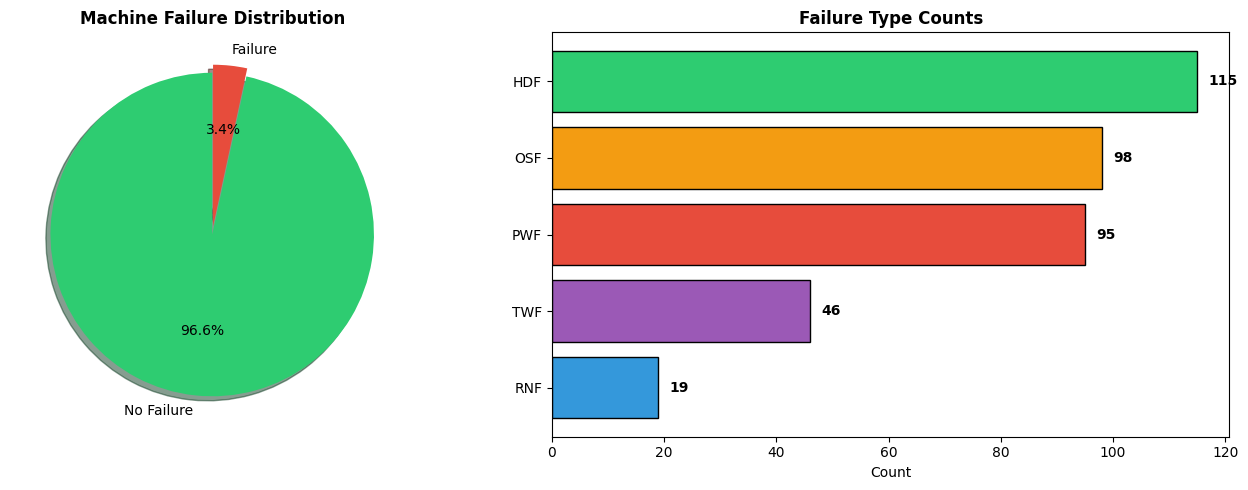

In [54]:
# VISUALIZATION 5: Target Variable Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart
ax1 = axes[0]
failure_counts_plot = df['Machine failure'].value_counts()
ax1.pie(failure_counts_plot, explode=(0, 0.05), labels=['No Failure', 'Failure'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, shadow=True)
ax1.set_title('Machine Failure Distribution', fontsize=12, fontweight='bold')

# Bar Chart
ax2 = axes[1]
failure_type_counts = df[failure_types].sum().sort_values(ascending=True)
bars = ax2.barh(failure_type_counts.index, failure_type_counts.values,
                color=['#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black')
ax2.set_xlabel('Count')
ax2.set_title('Failure Type Counts', fontsize=12, fontweight='bold')
for bar, val in zip(bars, failure_type_counts.values):
    ax2.text(val + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_05_failure_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

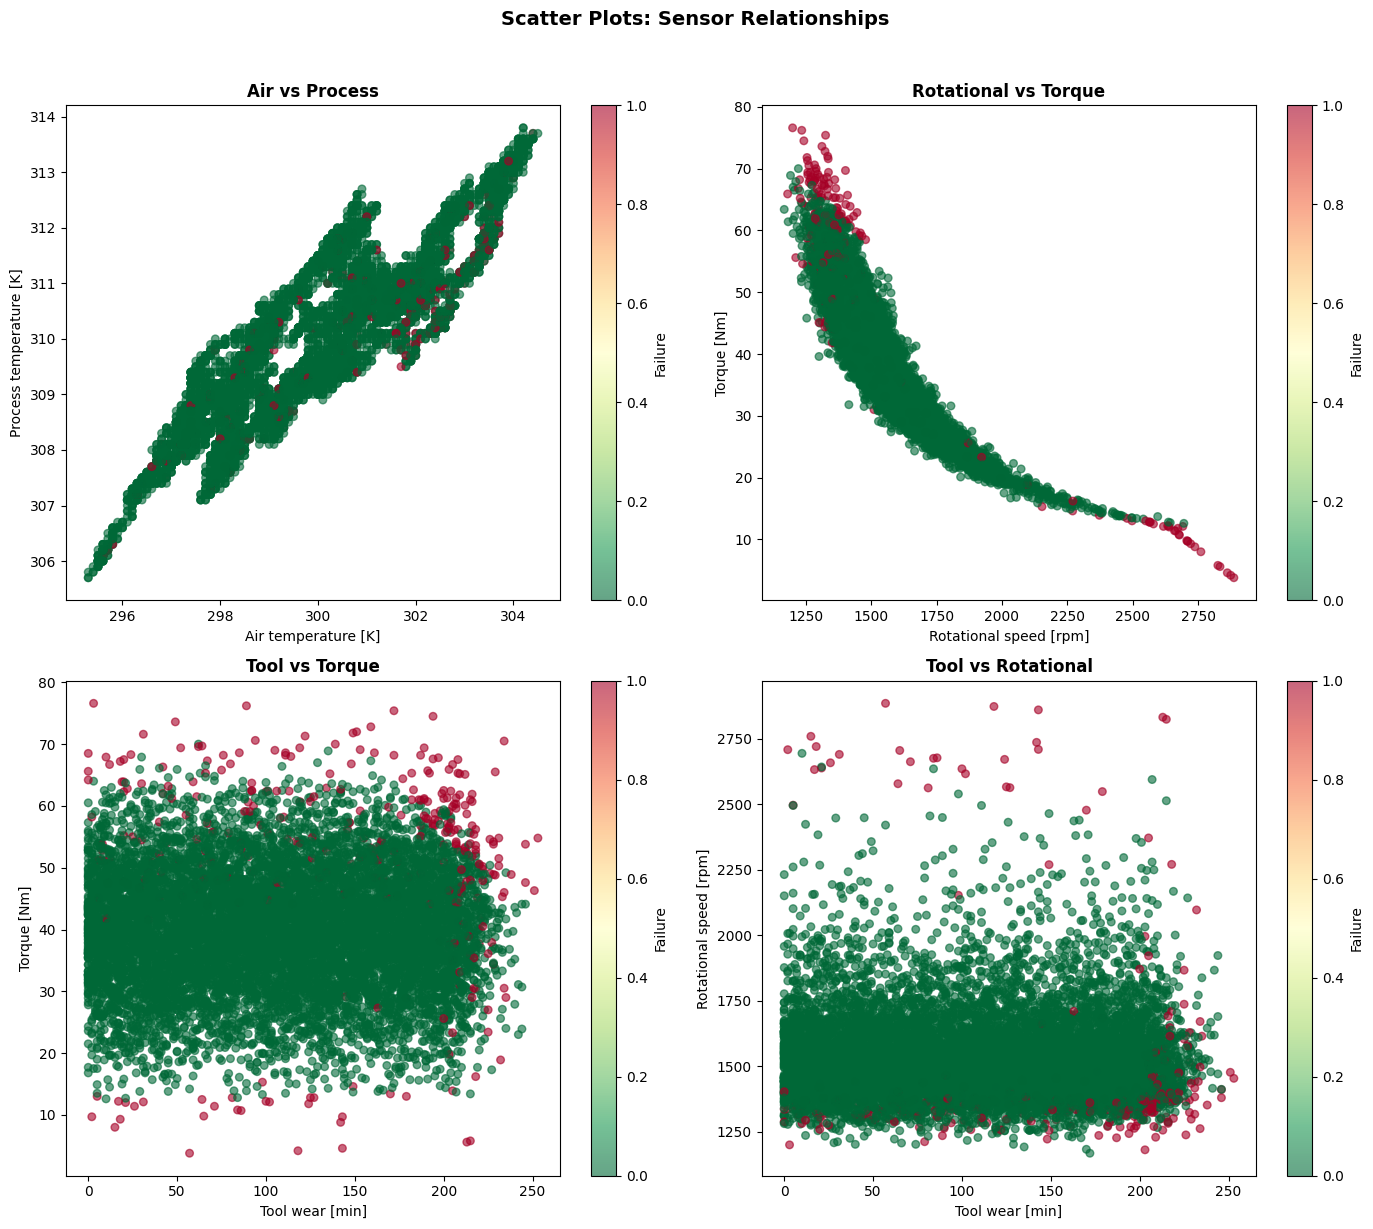

In [55]:
# VISUALIZATION 6: Scatter Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_pairs = [
    ('Air temperature [K]', 'Process temperature [K]'),
    ('Rotational speed [rpm]', 'Torque [Nm]'),
    ('Tool wear [min]', 'Torque [Nm]'),
    ('Tool wear [min]', 'Rotational speed [rpm]')
]

for ax, (x_col, y_col) in zip(axes.flatten(), scatter_pairs):
    scatter = ax.scatter(df[x_col], df[y_col], c=df['Machine failure'],
                         cmap='RdYlGn_r', alpha=0.6, s=30)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col.split()[0]} vs {y_col.split()[0]}', fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Failure')

plt.suptitle('Scatter Plots: Sensor Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_06_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

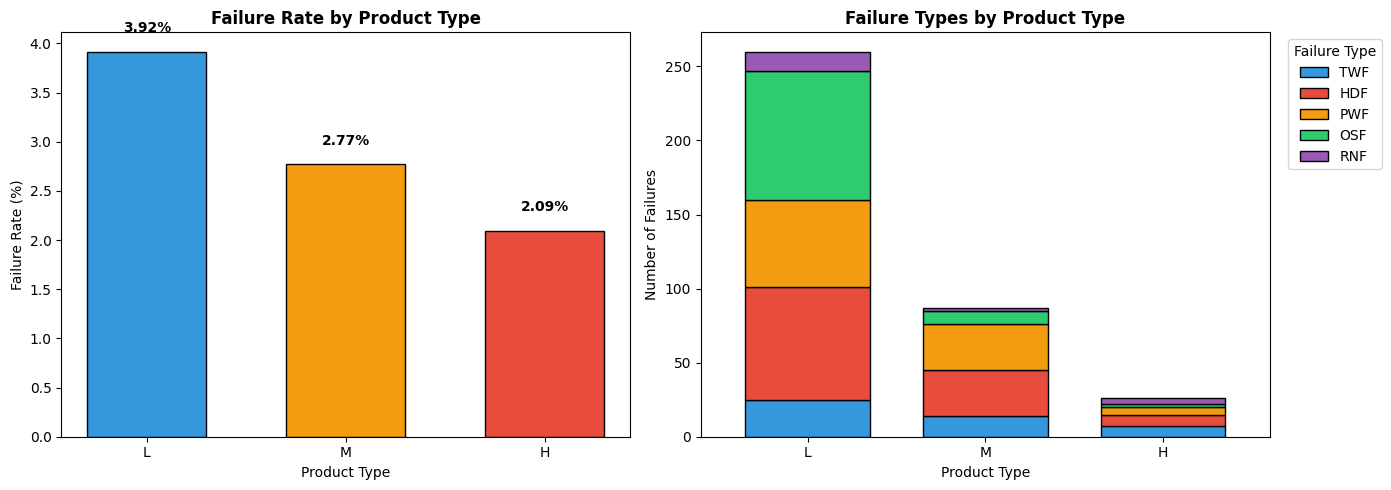

In [56]:
# VISUALIZATION 7: Failure Rate by Product Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - Failure rate
ax1 = axes[0]
failure_rate_type = df_analysis.groupby('Type')['Machine failure'].mean() * 100
failure_rate_type = failure_rate_type.reindex(['L', 'M', 'H'])
bars = ax1.bar(failure_rate_type.index, failure_rate_type.values,
               color=['#3498db', '#f39c12', '#e74c3c'], edgecolor='black', width=0.6)
ax1.set_xlabel('Product Type')
ax1.set_ylabel('Failure Rate (%)')
ax1.set_title('Failure Rate by Product Type', fontweight='bold')
for bar, val in zip(bars, failure_rate_type.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', fontweight='bold')

# Stacked bar - Failure types
ax2 = axes[1]
failure_by_type_df = df_analysis.groupby('Type')[failure_types].sum().reindex(['L', 'M', 'H'])
failure_by_type_df.plot(kind='bar', stacked=True, ax=ax2,
                         color=['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6'],
                         edgecolor='black', width=0.7)
ax2.set_xlabel('Product Type')
ax2.set_ylabel('Number of Failures')
ax2.set_title('Failure Types by Product Type', fontweight='bold')
ax2.legend(title='Failure Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('viz_07_failure_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

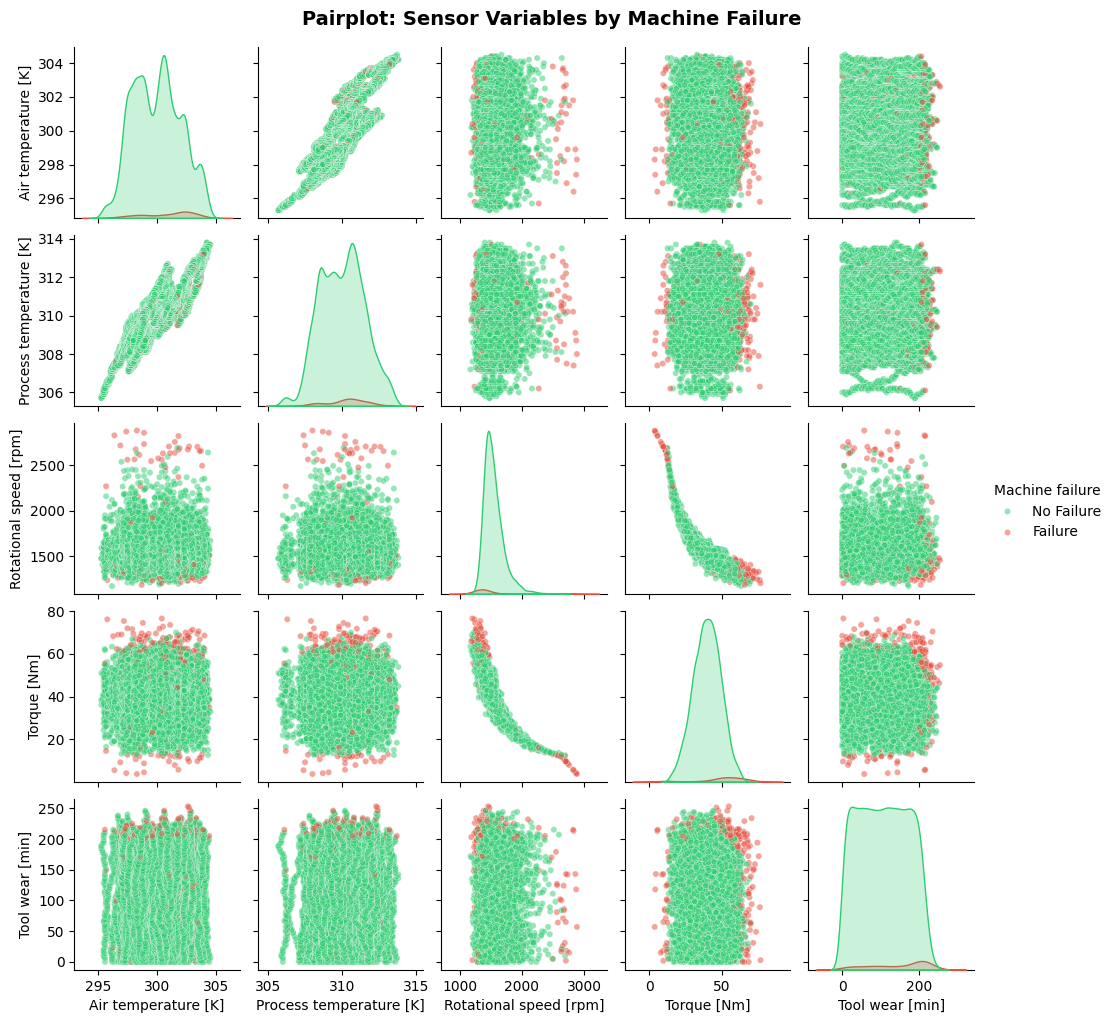

In [57]:
# VISUALIZATION 8: Pairplot
pairplot_df = df[sensor_cols + ['Machine failure']].copy()
pairplot_df['Machine failure'] = pairplot_df['Machine failure'].map({0: 'No Failure', 1: 'Failure'})

g = sns.pairplot(pairplot_df, hue='Machine failure',
                 palette={'No Failure': '#2ecc71', 'Failure': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20}, height=2)
g.fig.suptitle('Pairplot: Sensor Variables by Machine Failure', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('viz_08_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
print("="*80)
print("                   KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print("""
1. DATA QUALITY:
   - Dataset contains 10,000 records with 14 attributes
   - No missing values detected
   - No duplicate records found

2. CLASS IMBALANCE:
   - Machine failures occur in only ~3.4% of cases (339 out of 10,000)
   - Class Imbalance Ratio: 28.5:1
   - Need SMOTE, class weights, or undersampling for modeling

3. FAILURE TYPE ANALYSIS:
   - Heat Dissipation Failure (HDF): 115 cases (most common)
   - Overstrain Failure (OSF): 98 cases
   - Power Failure (PWF): 95 cases
   - Tool Wear Failure (TWF): 46 cases
   - Random Failure (RNF): 19 cases

4. PRODUCT TYPE INSIGHTS:
   - Low quality (L): 60% of products
   - Medium quality (M): 30% of products
   - High quality (H): 10% of products
   - High-quality products show higher failure rates (counterintuitive)

5. KEY PREDICTIVE INDICATORS:
   - Higher torque → more failures
   - Lower rotational speeds → more failures
   - Tool wear accumulation → increased failure probability
   - Temperature differentials indicate heat dissipation issues
""")

# Save cleaned datasets
df_clean.to_csv('ai4i2020_cleaned.csv', index=False)
df_analysis.to_csv('ai4i2020_analysis.csv', index=False)

print("\nCleaned datasets saved:")
print("  - ai4i2020_cleaned.csv (encoded categorical)")
print("  - ai4i2020_analysis.csv (original Type column)")

                   KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. DATA QUALITY:
   - Dataset contains 10,000 records with 14 attributes
   - No missing values detected
   - No duplicate records found

2. CLASS IMBALANCE:
   - Machine failures occur in only ~3.4% of cases (339 out of 10,000)
   - Class Imbalance Ratio: 28.5:1
   - Need SMOTE, class weights, or undersampling for modeling

3. FAILURE TYPE ANALYSIS:
   - Heat Dissipation Failure (HDF): 115 cases (most common)
   - Overstrain Failure (OSF): 98 cases  
   - Power Failure (PWF): 95 cases
   - Tool Wear Failure (TWF): 46 cases
   - Random Failure (RNF): 19 cases

4. PRODUCT TYPE INSIGHTS:
   - Low quality (L): 60% of products
   - Medium quality (M): 30% of products
   - High quality (H): 10% of products
   - High-quality products show higher failure rates (counterintuitive)

5. KEY PREDICTIVE INDICATORS:
   - Higher torque → more failures
   - Lower rotational speeds → more failures
   - Tool wear accumulation → increased fa